In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


### Tensors

In [3]:
torch.__version__

'2.10.0'

In [4]:
scalar = torch.tensor(7)
print(scalar.ndim)
scalar.device

0


device(type='cpu')

In [5]:
scalar_on_gpu = scalar.to(device)

In [6]:
scalar.device

device(type='cpu')

In [7]:
vector = torch.tensor([7, 7])
print(vector.ndim)
print(vector.shape)
vector

1
torch.Size([2])


tensor([7, 7])

In [8]:
matrix = torch.tensor([[7, 8], 
                       [8, 9]])
print(matrix.ndim)
print(matrix.shape)
matrix

2
torch.Size([2, 2])


tensor([[7, 8],
        [8, 9]])

In [9]:
tensor = torch.tensor([[[1, 2, 3],
                        [3, 6, 9],
                        [2, 4, 5]]])
print(tensor.ndim)
print(tensor.shape)
tensor

3
torch.Size([1, 3, 3])


tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [10]:
random_tensor = torch.rand(size=(1, 3, 3))
random_tensor

tensor([[[0.3540, 0.5776, 0.5435],
         [0.5759, 0.7484, 0.3360],
         [0.6140, 0.4181, 0.7458]]])

### Multiplication

In [11]:
# Element-wise
tensor_1 = torch.rand(size=(1, 2, 2))
tensor_2 = torch.rand(size=(1, 2, 2))
tensor_1 * tensor_2

tensor([[[0.0450, 0.5386],
         [0.7186, 0.7067]]])

In [12]:
# Matrix multiplication
tensor_1 = torch.rand(size=(1, 2, 3))
tensor_2 = torch.rand(size=(1, 3, 3))
tensor_1 @ tensor_2

torch.matmul(tensor_1, tensor_2)

tensor([[[0.2178, 0.2461, 0.7811],
         [0.5187, 0.8022, 2.0612]]])

### Linear Regression

In [13]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = torch.nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = torch.nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor):
        return self.weights * x + bias


model = LinearRegressionModel()

In [14]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = model.to(device=device)
X_train = X_train.to(device=device)
X_test = X_test.to(device=device)
y_train = y_train.to(device=device)
y_test = y_test.to(device=device)

Epoch: 0 | Train Loss: 0.15613622963428497 | Test Loss: 0.1783258616924286 
Epoch: 10 | Train Loss: 0.13767582178115845 | Test Loss: 0.15724192559719086 
Epoch: 20 | Train Loss: 0.12139806896448135 | Test Loss: 0.1386508196592331 
Epoch: 30 | Train Loss: 0.10704486072063446 | Test Loss: 0.1222577691078186 
Epoch: 40 | Train Loss: 0.09438866376876831 | Test Loss: 0.10780291259288788 
Epoch: 50 | Train Loss: 0.08322884887456894 | Test Loss: 0.09505710750818253 
Epoch: 60 | Train Loss: 0.0733884796500206 | Test Loss: 0.08381825685501099 
Epoch: 70 | Train Loss: 0.0647115632891655 | Test Loss: 0.07390820980072021 
Epoch: 80 | Train Loss: 0.057060547173023224 | Test Loss: 0.06516984105110168 
Epoch: 90 | Train Loss: 0.050314128398895264 | Test Loss: 0.05746464803814888 
Epoch: 100 | Train Loss: 0.04436536133289337 | Test Loss: 0.05067043751478195 
Epoch: 110 | Train Loss: 0.039119936525821686 | Test Loss: 0.04467955604195595 
Epoch: 120 | Train Loss: 0.034494683146476746 | Test Loss: 0.0393

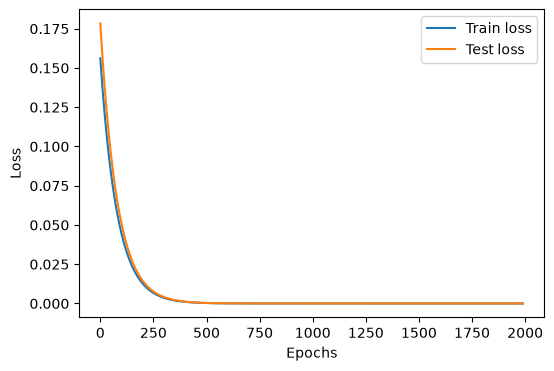

In [15]:
epochs = 2000
loss_fn = torch.nn.MSELoss() # torch.nn.L1Loss() 
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training
    model.train()                   # Set model in training mode
    y_pred = model(X_train)         # Forward pass on train data
    loss = loss_fn(y_pred, y_train) # Calculate the loss
    optimizer.zero_grad()           # Accumulated by default, set to zero so they are recalculated
    loss.backward()                 # Loss backpropagation w/ respect to every model parameter
    optimizer.step()                # Update parameters with `requires_grad=True`

    ### Testing
    model.eval()                    # Set model in test mode

    with torch.inference_mode(): 
      test_pred = model(X_test)                                 # Forward pass on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float))  # Caculate loss on test data

      # Print log
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())
            print(f"Epoch: {epoch} | Train Loss: {loss} | Test Loss: {test_loss} ")


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(epoch_count, train_loss_values, label="Train loss")
ax.plot(epoch_count, test_loss_values, label="Test loss")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

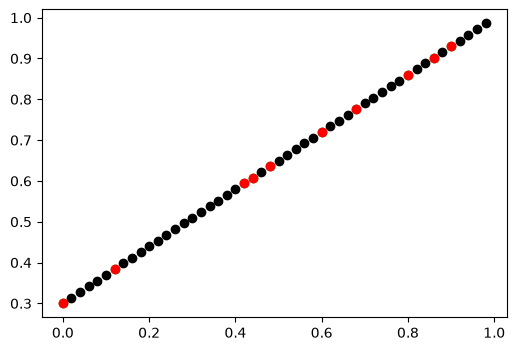

weights
tensor([0.7000])
bias
tensor([1.5216])


In [16]:
model.eval()

with torch.inference_mode():
    y_preds = model(X_test)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X_train.detach().cpu().numpy(), y_train.detach().cpu().numpy(), color='black')
ax.scatter(X_test.detach().cpu().numpy(), y_test.detach().cpu().numpy(), color='green')
ax.scatter(X_test.detach().cpu().numpy(), y_preds.detach().cpu().numpy(), color='red')
plt.show()

for name, param in model.named_parameters():
    print(name)
    print(param.detach().cpu())

### Linear layer

$ y = A \cdot x + b$

In [20]:
class LinearRegressionModel2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = torch.nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear_layer(x)

model2 = LinearRegressionModel2()
model2 = model2.to(device=device)

In [21]:
loss_fn = torch.nn.L1Loss() # torch.nn.MSELoss()
optimizer = torch.optim.SGD(params=model2.parameters(), lr=0.01)

epochs = 1000

for epoch in range(epochs):
    model2.train()
    y_pred = model2(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model2.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.4770582318305969 | Test loss: 2.500414893802372e-06
Epoch: 100 | Train loss: 0.1912660151720047 | Test loss: 2.500414893802372e-06
Epoch: 200 | Train loss: 0.13713224232196808 | Test loss: 2.500414893802372e-06
Epoch: 300 | Train loss: 0.0863419622182846 | Test loss: 2.500414893802372e-06
Epoch: 400 | Train loss: 0.03560161590576172 | Test loss: 2.500414893802372e-06
Epoch: 500 | Train loss: 0.006562987808138132 | Test loss: 2.500414893802372e-06
Epoch: 600 | Train loss: 0.006562987808138132 | Test loss: 2.500414893802372e-06
Epoch: 700 | Train loss: 0.006562987808138132 | Test loss: 2.500414893802372e-06
Epoch: 800 | Train loss: 0.006562987808138132 | Test loss: 2.500414893802372e-06
Epoch: 900 | Train loss: 0.006562987808138132 | Test loss: 2.500414893802372e-06


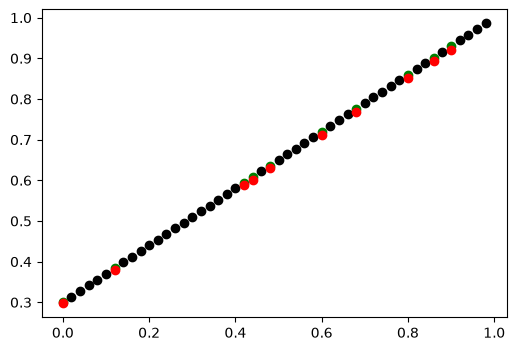

linear_layer.weight
tensor([[0.6918]])
linear_layer.bias
tensor([0.2974])


In [22]:
model2.eval()

with torch.inference_mode():
    y_preds = model2(X_test)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X_train.detach().cpu().numpy(), y_train.detach().cpu().numpy(), color='black')
ax.scatter(X_test.detach().cpu().numpy(), y_test.detach().cpu().numpy(), color='green')
ax.scatter(X_test.detach().cpu().numpy(), y_preds.detach().cpu().numpy(), color='red')
plt.show()

for name, param in model2.named_parameters():
    print(name)
    print(param.detach().cpu())

### Binary Classification

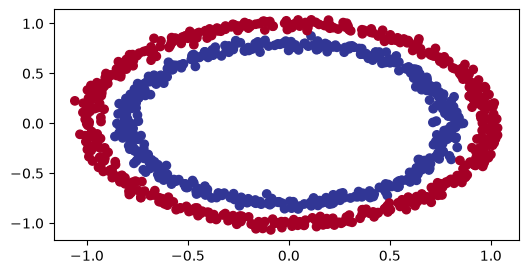

In [55]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)
circles = pd.DataFrame({'X1': X[:, 0], 
                        'X2': X[:, 1],
                        'label': y})

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.scatter(x=circles['X1'], y=circles['X2'], c=circles['label'], cmap=plt.cm.RdYlBu);
plt.show()



X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [56]:
class CircleModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = torch.nn.Linear(in_features=2, out_features=10)
        self.layer2 = torch.nn.Linear(in_features=10, out_features=10)
        self.layer3 = torch.nn.Linear(in_features=10, out_features=1)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        return self.layer3(self.layer2(self.relu(self.layer1(x))))

model = CircleModel()

In [57]:
loss_fn = torch.nn.BCEWithLogitsLoss() # Binary cross entropy
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)
epochs = 1000


def accuracy_fn(y_pred, y_true):
    correct = torch.eq(y_pred, y_true).sum().item()
    return 100 * correct / len(y_pred) 


for epoch in range(epochs):
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
      test_logits = model(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print log
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.3f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.2f}%")




Epoch: 0 | Loss: 0.698, Accuracy: 50.88% | Test Loss: 0.705, Test Accuracy: 46.50%
Epoch: 100 | Loss: 0.689, Accuracy: 56.88% | Test Loss: 0.691, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.686, Accuracy: 53.75% | Test Loss: 0.689, Test Accuracy: 47.50%
Epoch: 300 | Loss: 0.682, Accuracy: 59.25% | Test Loss: 0.687, Test Accuracy: 51.00%
Epoch: 400 | Loss: 0.677, Accuracy: 62.75% | Test Loss: 0.682, Test Accuracy: 59.00%
Epoch: 500 | Loss: 0.671, Accuracy: 59.62% | Test Loss: 0.675, Test Accuracy: 59.50%
Epoch: 600 | Loss: 0.662, Accuracy: 59.12% | Test Loss: 0.665, Test Accuracy: 61.00%
Epoch: 700 | Loss: 0.648, Accuracy: 60.88% | Test Loss: 0.651, Test Accuracy: 62.50%
Epoch: 800 | Loss: 0.618, Accuracy: 71.50% | Test Loss: 0.622, Test Accuracy: 68.50%
Epoch: 900 | Loss: 0.542, Accuracy: 95.12% | Test Loss: 0.555, Test Accuracy: 91.50%


In [58]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """
    Plots decision boundaries of model predicting on X in comparison to y
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

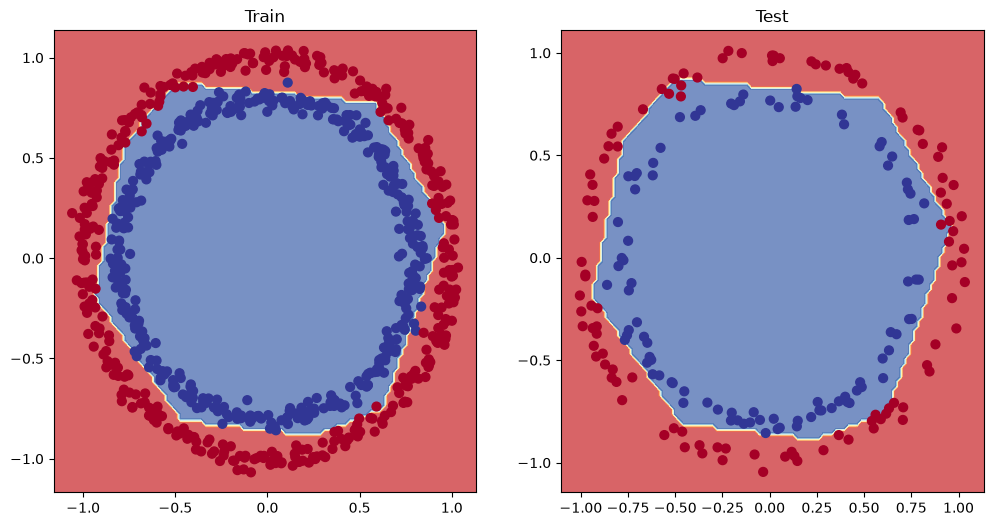

In [59]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test) # model_3 = has non-linearity

### Multiclass Classification

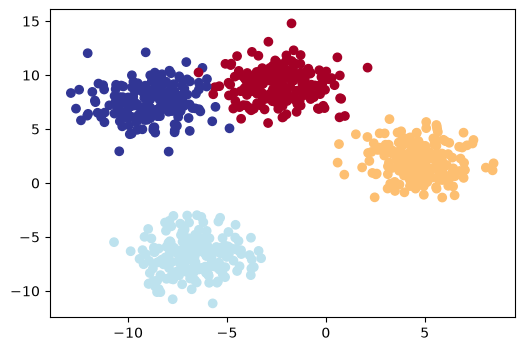

In [69]:
from sklearn.datasets import make_blobs

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000, 
                            n_features=NUM_FEATURES, 
                            centers=NUM_CLASSES, 
                            cluster_std=1.5, 
                            random_state=RANDOM_SEED)

X = torch.from_numpy(X_blob).type(torch.float)
y = torch.from_numpy(y_blob).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu)
plt.show()

In [70]:
class BlobModel(torch.nn.Module):
    def __init__(self, input_feats=2, output_feats=4, hidden_nodes=8):
        super().__init__()
        self.linear_layer1 = torch.nn.Linear(in_features=input_feats, out_features=hidden_nodes)
        self.linear_layer2 = torch.nn.Linear(in_features=hidden_nodes, out_features=hidden_nodes)
        self.linear_layer3 = torch.nn.Linear(in_features=hidden_nodes, out_features=output_feats)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        return self.linear_layer3(self.linear_layer2(self.relu(self.linear_layer1(x))))

model = BlobModel(input_feats=NUM_FEATURES, output_feats=NUM_CLASSES, hidden_nodes=8)

In [71]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

epochs = 1000

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    if epoch % 25 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.3f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.2f}%")



Epoch: 0 | Loss: 1.415, Accuracy: 44.75% | Test Loss: 1.004, Test Accuracy: 49.50%
Epoch: 25 | Loss: 0.069, Accuracy: 99.25% | Test Loss: 0.079, Test Accuracy: 99.50%
Epoch: 50 | Loss: 0.038, Accuracy: 99.25% | Test Loss: 0.051, Test Accuracy: 99.50%
Epoch: 75 | Loss: 0.029, Accuracy: 99.25% | Test Loss: 0.044, Test Accuracy: 99.50%
Epoch: 100 | Loss: 0.025, Accuracy: 99.38% | Test Loss: 0.042, Test Accuracy: 99.50%
Epoch: 125 | Loss: 0.022, Accuracy: 99.38% | Test Loss: 0.040, Test Accuracy: 99.50%
Epoch: 150 | Loss: 0.021, Accuracy: 99.38% | Test Loss: 0.040, Test Accuracy: 99.50%
Epoch: 175 | Loss: 0.020, Accuracy: 99.38% | Test Loss: 0.040, Test Accuracy: 99.50%
Epoch: 200 | Loss: 0.019, Accuracy: 99.38% | Test Loss: 0.040, Test Accuracy: 99.50%
Epoch: 225 | Loss: 0.018, Accuracy: 99.38% | Test Loss: 0.040, Test Accuracy: 99.50%
Epoch: 250 | Loss: 0.018, Accuracy: 99.38% | Test Loss: 0.040, Test Accuracy: 99.50%
Epoch: 275 | Loss: 0.017, Accuracy: 99.38% | Test Loss: 0.041, Test Ac

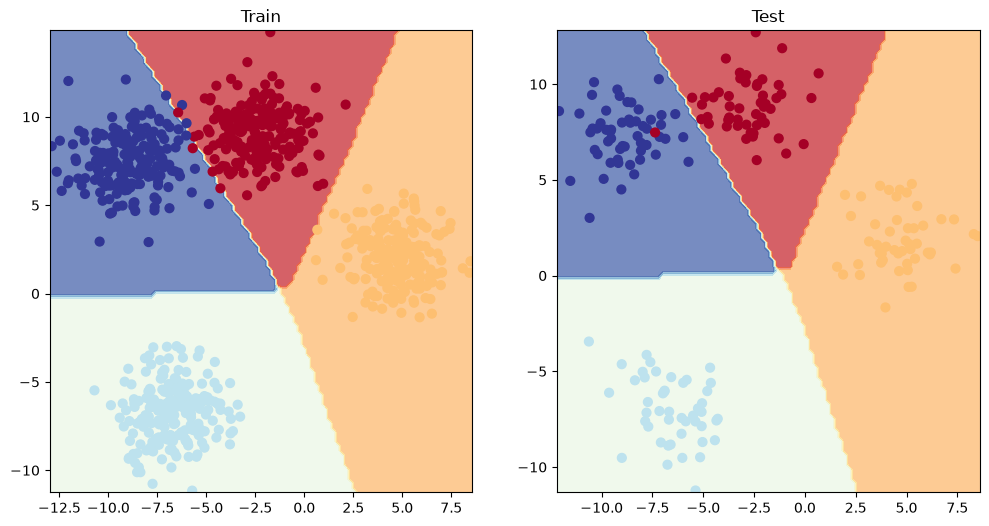

In [72]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)